<a href="https://colab.research.google.com/github/AhmadKevin000/PCVK_Ganjil2026/blob/main/week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from pathlib import Path
import sys
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/gdrive')

DATA_DIR = next((p for p in [Path('Images'), Path('images'),
    Path('/content/gdrive/MyDrive/Matkul Sem 5/PCVK/Images'),
    Path('/content/gdrive/MyDrive/Matkul Sem 5/PCVK')] if p.is_dir()), Path('Images'))
OUTPUT_DIR = Path('hasil_week3')
OUTPUT_DIR.mkdir(exist_ok=True)
INTERACTIVE = True

def read_image(name, gray=False):
    path = DATA_DIR / name
    image = cv.imread(str(path), cv.IMREAD_GRAYSCALE if gray else cv.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f'Citra tidak dapat dibaca: {path}. Periksa DATA_DIR.')
    return image

def uint8(image):
    return np.clip(np.rint(image), 0, 255).astype(np.uint8)

def ask_number(prompt, default, valid=lambda x: True):
    if not INTERACTIVE:
        return default
    while True:
        try:
            value = float(input(f'{prompt} [default {default}]: ') or default)
            if np.isfinite(value) and valid(value):
                return value
        except ValueError:
            pass
        print('Masukan tidak valid; gunakan angka dalam rentang yang diminta.')

def show_results(filename, images, titles, columns=2):
    rows = (len(images) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 4 * rows), squeeze=False)
    for ax, image, title in zip(axes.flat, images, titles):
        ax.imshow(image if image.ndim == 2 else cv.cvtColor(image, cv.COLOR_BGR2RGB),
                  cmap='gray', vmin=0, vmax=255)
        ax.set_title(title)
    for ax in axes.flat:
        ax.axis('off')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def gamma_correction(image, gamma):
    if not np.isfinite(gamma) or gamma <= 0:
        raise ValueError('Gamma harus positif dan finite.')
    return uint8(255 * (image.astype(np.float64) / 255) ** (1 / gamma))

print('Dataset:', DATA_DIR.resolve())
print('Hasil:', OUTPUT_DIR.resolve())

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Dataset: /content/gdrive/MyDrive/Matkul Sem 5/PCVK/Images
Hasil: /content/hasil_week3


 Mengubah tingkat kecerahan citra 
-----------------------------
Kecerahan (-255 sampai 255) [default 30]: 30


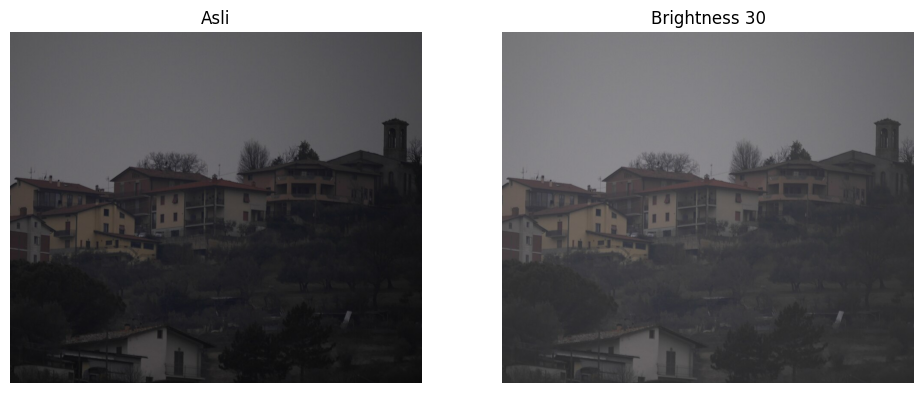

In [11]:
import cv2 as cv
import numpy as np

print(' Mengubah tingkat kecerahan citra ')
print('-----------------------------')

brightness = int(ask_number('Kecerahan (-255 sampai 255)', 30, lambda x: x.is_integer() and -255 <= x <= 255))

original = read_image('houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(
                int(original[y, x, c]) + brightness, 0, 255
            )

final_frame = cv.hconcat((original, brightness_image))
show_results('00_brightness.png', [original, brightness_image], ['Asli', f'Brightness {brightness}'])

In [7]:
peppers = cv.imread('/content/drive/MyDrive/Matkul Sem 5/PCVK/Images/peppers.jpg')
houses = cv.imread('/content/drive/MyDrive/Matkul Sem 5/PCVK/Images/houses.jpg')
print('Ukuran peppers:', peppers.shape, '| houses:', houses.shape)

Ukuran peppers: (498, 626, 3) | houses: (820, 960, 3)


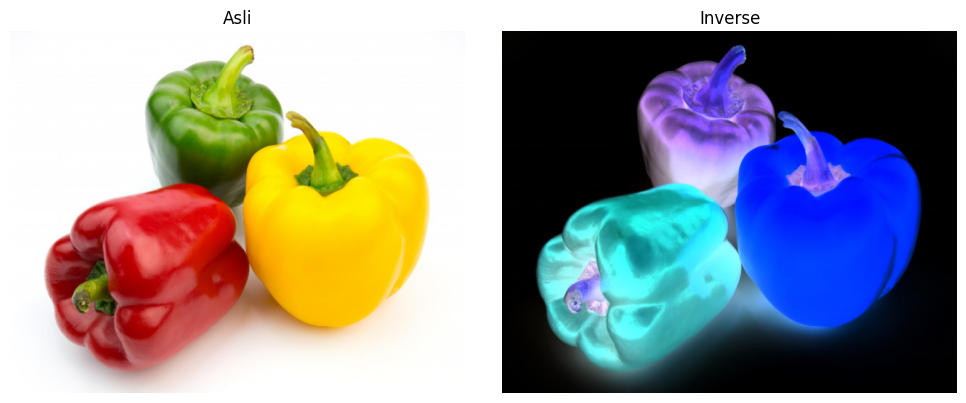

In [12]:
inverse_image = 255 - peppers
show_results('01_inverse.png', [peppers, inverse_image], ['Asli', 'Inverse'])

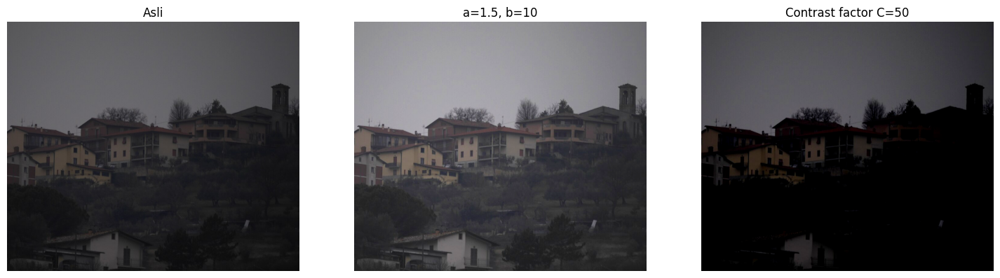

In [13]:
alpha, beta, contrast = 1.5, 10, 50
contrast_linear = uint8(alpha * houses.astype(np.float64) + beta)
factor = 259 * (contrast + 255) / (255 * (259 - contrast))
contrast_factor = uint8(factor * (houses.astype(np.float64) - 128) + 128)
show_results('02_contrast.png', [houses, contrast_linear, contrast_factor],
             ['Asli', 'a=1.5, b=10', 'Contrast factor C=50'], 3)

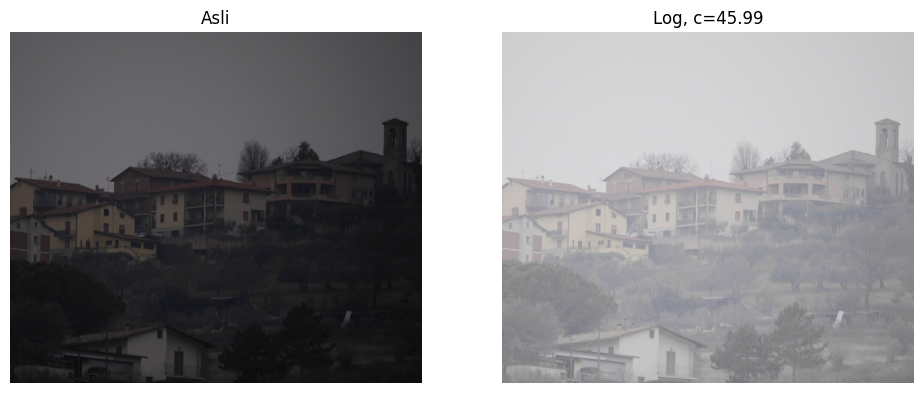

In [14]:
c_log = 255 / np.log1p(255)
log_image = uint8(c_log * np.log1p(houses.astype(np.float64)))
show_results('03_log.png', [houses, log_image], ['Asli', f'Log, c={c_log:.2f}'])

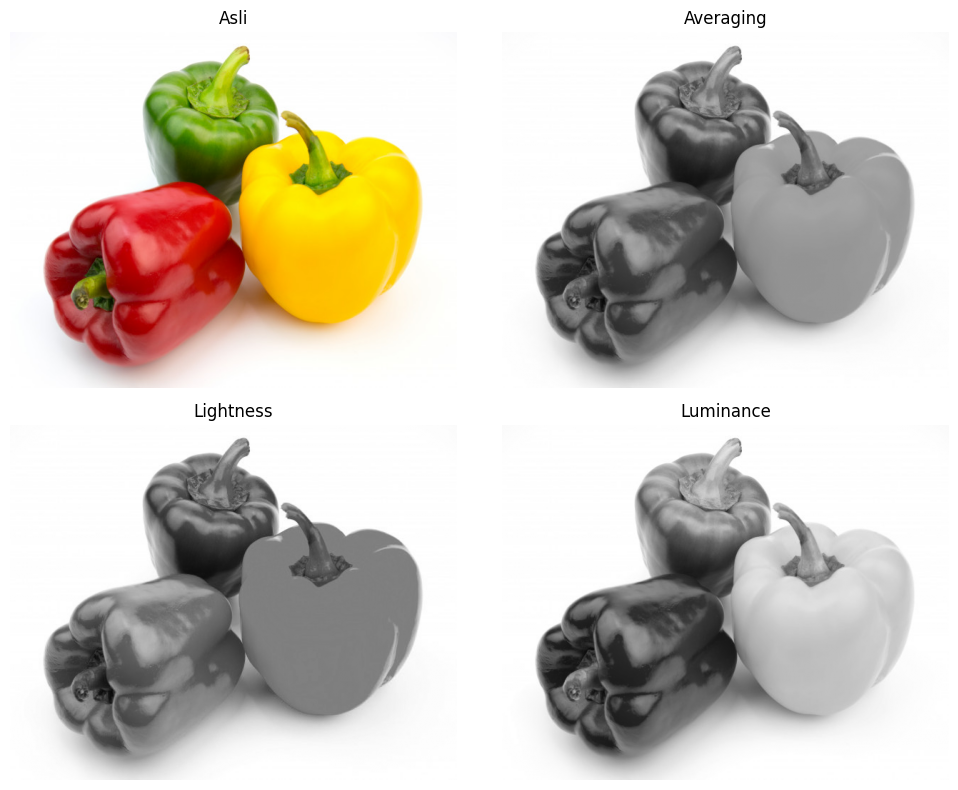

In [15]:
pixels = peppers.astype(np.float64)
blue, green, red = cv.split(pixels)
gray_average = uint8(pixels.mean(axis=2))
gray_lightness = uint8((pixels.max(axis=2) + pixels.min(axis=2)) / 2)
gray_luminance = uint8(0.21 * red + 0.72 * green + 0.07 * blue)
show_results('04_grayscale.png', [peppers, gray_average, gray_lightness, gray_luminance],
             ['Asli', 'Averaging', 'Lightness', 'Luminance'])

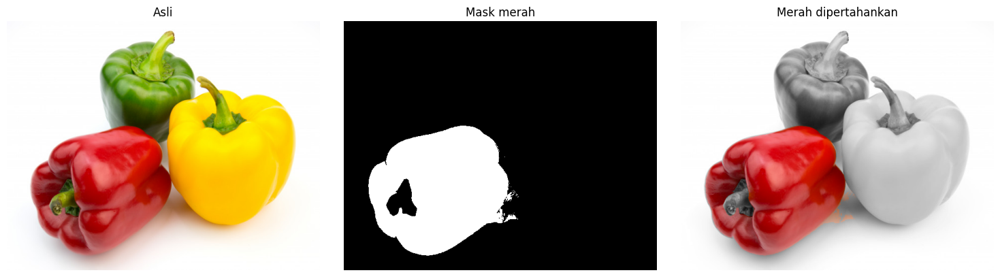

In [16]:
hsv = cv.cvtColor(peppers, cv.COLOR_BGR2HSV)
red_mask = cv.bitwise_or(cv.inRange(hsv, (0, 80, 40), (10, 255, 255)),
                         cv.inRange(hsv, (170, 80, 40), (179, 255, 255)))
selective_image = cv.cvtColor(gray_luminance, cv.COLOR_GRAY2BGR)
selective_image[red_mask > 0] = peppers[red_mask > 0]
show_results('05_selective.png', [peppers, red_mask, selective_image], ['Asli', 'Mask merah', 'Merah dipertahankan'], 3)

Masukkan Gamma (>0) [default 3.0]: 3.0


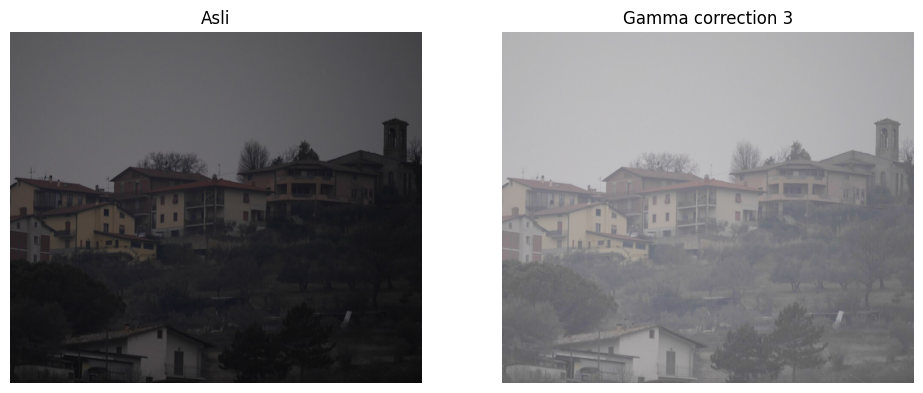

In [17]:
gamma = ask_number('Masukkan Gamma (>0)', 3.0, lambda x: x > 0)
gamma_image = gamma_correction(houses, gamma)
show_results('06_gamma.png', [houses, gamma_image], ['Asli', f'Gamma correction {gamma:g}'])

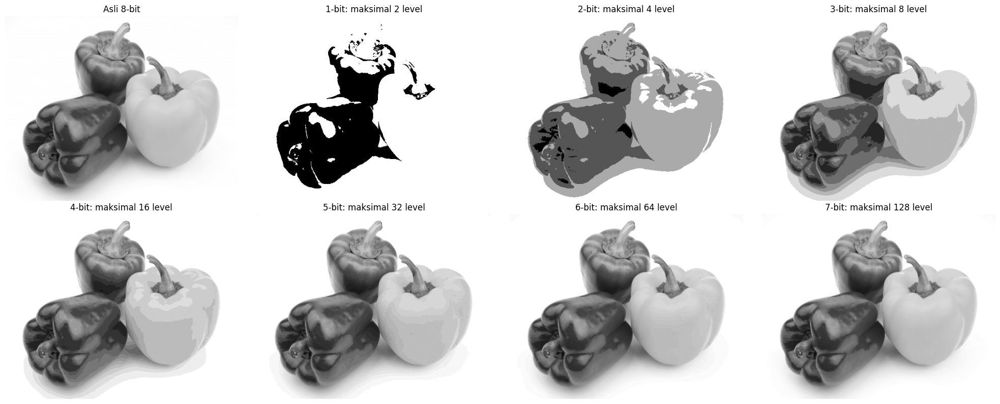

1-bit: 2 intensitas aktual
2-bit: 4 intensitas aktual
3-bit: 8 intensitas aktual
4-bit: 16 intensitas aktual
5-bit: 31 intensitas aktual
6-bit: 63 intensitas aktual
7-bit: 125 intensitas aktual


In [18]:
def image_depth(image, bits):
    if not isinstance(bits, (int, np.integer)) or not 1 <= bits <= 8:
        raise ValueError('Bit depth harus integer 1–8.')
    level = 255 / (2 ** bits - 1)
    return uint8(np.rint(image.astype(np.float64) / level) * level)

gray_depth = read_image('peppers.jpg', gray=True)
depth_images = [image_depth(gray_depth, bits) for bits in range(1, 8)]
show_results('07_depth.png', [gray_depth] + depth_images,
             ['Asli 8-bit'] + [f'{b}-bit: maksimal {2**b} level' for b in range(1, 8)], 4)
for bits, image in enumerate(depth_images, 1):
    print(f'{bits}-bit: {len(np.unique(image))} intensitas aktual')

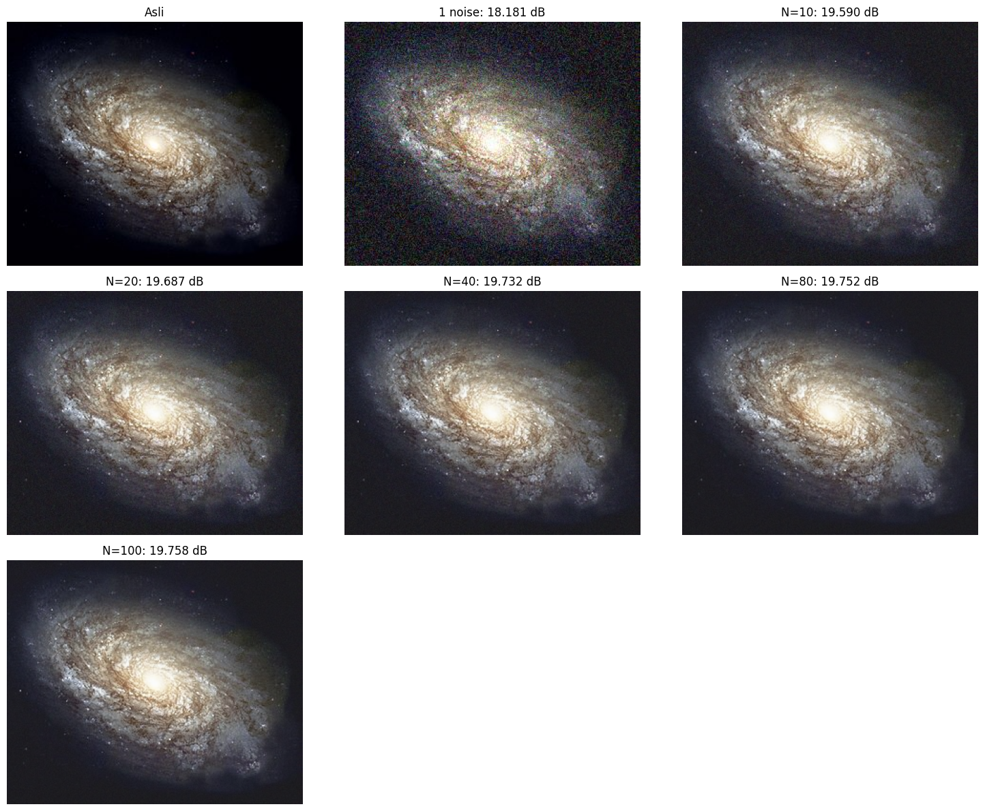

| N | Hasil | PSNR (dB) | Kenaikan (dB) |
|---|---|---:|---:|
| 10 | ![Average 10](hasil_week3/average_10.png) | 19.5905 | — |
| 20 | ![Average 20](hasil_week3/average_20.png) | 19.6871 | 0.0966 |
| 40 | ![Average 40](hasil_week3/average_40.png) | 19.7319 | 0.0448 |
| 80 | ![Average 80](hasil_week3/average_80.png) | 19.7518 | 0.0199 |
| 100 | ![Average 100](hasil_week3/average_100.png) | 19.7580 | 0.0062 |

Kenaikan pertama di bawah 1 dB terjadi pada 10 → 20 citra. Bias rata-rata hasil 100 citra terhadap referensi (B,G,R): [25.928, 26.248, 26.045]. Bias yang tidak nol tidak hilang hanya dengan menambah jumlah citra. Jumlah citra lebih banyak tidak menjamin peningkatan besar pada setiap tahap. Tahap 80 → 100 hanya menambah 25% citra; peningkatan idealnya sekitar 0.97 dB. Batas 1 dB merupakan kriteria praktikum, bukan signifikansi statistik.

6291

In [19]:
import glob
import re
import csv

def psnr(reference, result):
    if reference.shape != result.shape:
        raise ValueError('Ukuran citra PSNR harus sama.')
    mse = np.mean((reference.astype(np.float64) - result.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else float(10 * np.log10(255 ** 2 / mse))

def natural_key(path):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'([0-9]+)', Path(path).name)]

galaxy = read_image('galaxy.jpg')
noise_files = sorted(glob.glob(str(DATA_DIR / 'noises' / '*.jpg')), key=natural_key)
if len(noise_files) < 100:
    raise ValueError(f'Diperlukan 100 citra noise asli; ditemukan {len(noise_files)}.')
counts = [10, 20, 40, 80, 100]
accumulator = np.zeros(galaxy.shape, dtype=np.float64)
denoised_images, psnr_rows = [], []
for n, path in enumerate(noise_files[:100], 1):
    noisy = cv.imread(path)
    if noisy is None or noisy.shape != galaxy.shape:
        raise ValueError(f'Citra noise rusak atau ukurannya berbeda: {path}')
    if n == 1:
        first_noisy = noisy.copy()
    accumulator += noisy
    if n in counts:
        result = uint8(accumulator / n)
        value = psnr(galaxy, result)
        gain = None if not psnr_rows else value - psnr_rows[-1][1]
        psnr_rows.append((n, value, gain))
        denoised_images.append(result)
        cv.imwrite(str(OUTPUT_DIR / f'average_{n}.png'), result)
show_results('08_denoising.png', [galaxy, first_noisy] + denoised_images,
    ['Asli', f'1 noise: {psnr(galaxy, first_noisy):.3f} dB'] +
    [f'N={n}: {p:.3f} dB' for n, p, _ in psnr_rows], 3)
with (OUTPUT_DIR / 'psnr.csv').open('w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['jumlah_citra', 'psnr_db', 'kenaikan_db'])
    writer.writerows(psnr_rows)
table = '| N | Hasil | PSNR (dB) | Kenaikan (dB) |\n|---|---|---:|---:|\n'
for n, p, gain in psnr_rows:
    gain_text = '—' if gain is None else f'{gain:.4f}'
    table += f'| {n} | ![Average {n}](average_{n}.png) | {p:.4f} | {gain_text} |\n'
small_gains = [(psnr_rows[i-1][0], row[0]) for i, row in enumerate(psnr_rows) if i > 0 and row[2] < 1.0]
if small_gains:
    start, end = small_gains[0]
    conclusion = f'Kenaikan pertama di bawah 1 dB terjadi pada {start} → {end} citra. '
else:
    conclusion = 'Belum ada kenaikan di bawah 1 dB pada tahap yang diuji. '
bias_bgr = (denoised_images[-1].astype(np.float64) - galaxy.astype(np.float64)).mean(axis=(0, 1))
conclusion += f'Bias rata-rata hasil 100 citra terhadap referensi (B,G,R): {bias_bgr.round(3).tolist()}. '
conclusion += ('Bias yang tidak nol tidak hilang hanya dengan menambah jumlah citra. '
    'Jumlah citra lebih banyak tidak menjamin peningkatan besar pada setiap tahap. '
    'Tahap 80 → 100 hanya menambah 25% citra; peningkatan idealnya sekitar 0.97 dB. '
    'Batas 1 dB merupakan kriteria praktikum, bukan signifikansi statistik.')
display(Markdown(table.replace('](average_', '](hasil_week3/average_') + '\n' + conclusion))
(OUTPUT_DIR / 'psnr.md').write_text('# Hasil pengukuran PSNR\n\n' + table + '\n' + conclusion, encoding='utf-8')
(OUTPUT_DIR / 'noise_manifest.txt').write_text('\n'.join(str(p) for p in noise_files[:100]), encoding='utf-8')

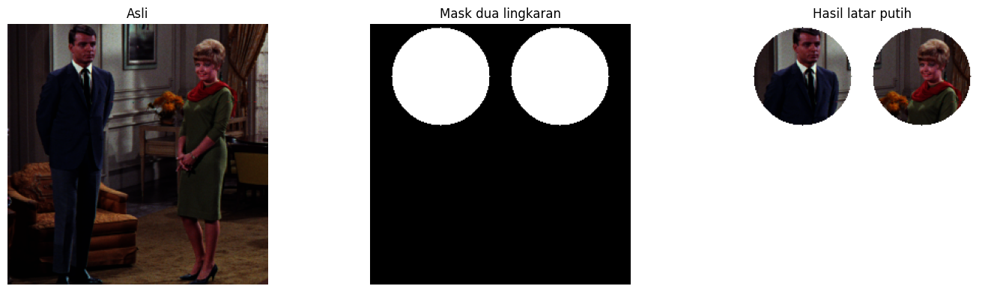

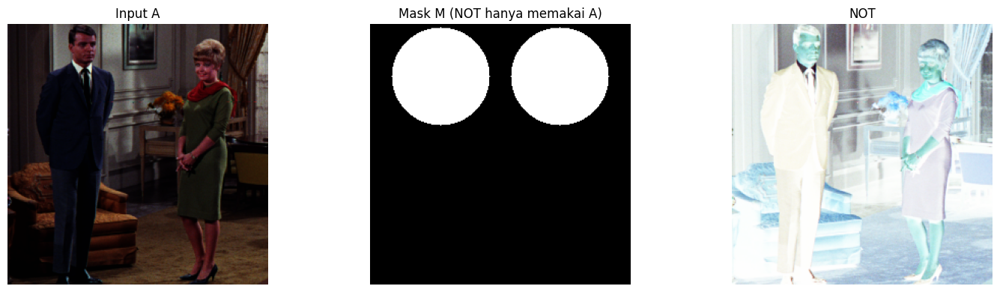

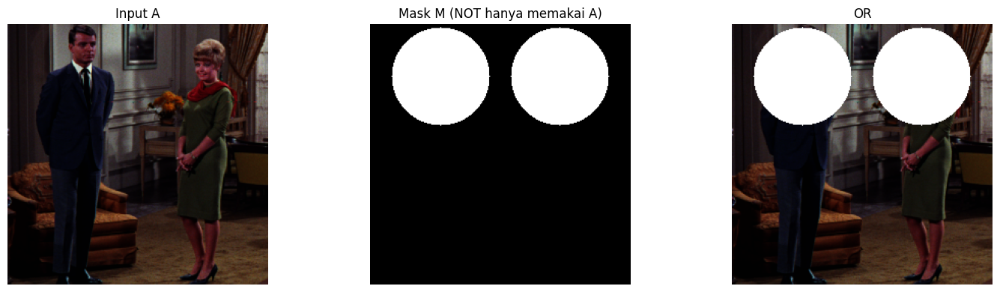

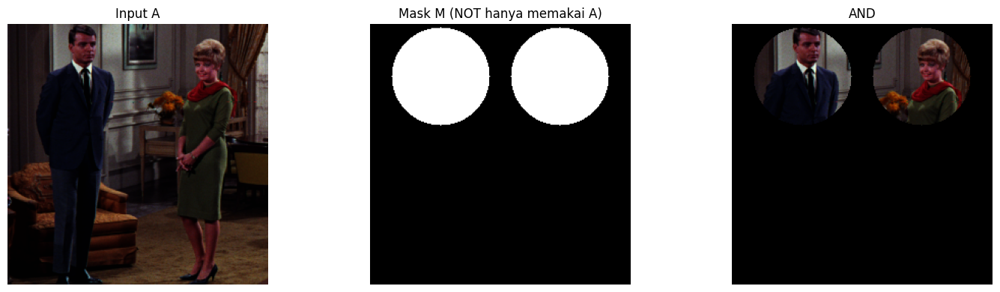

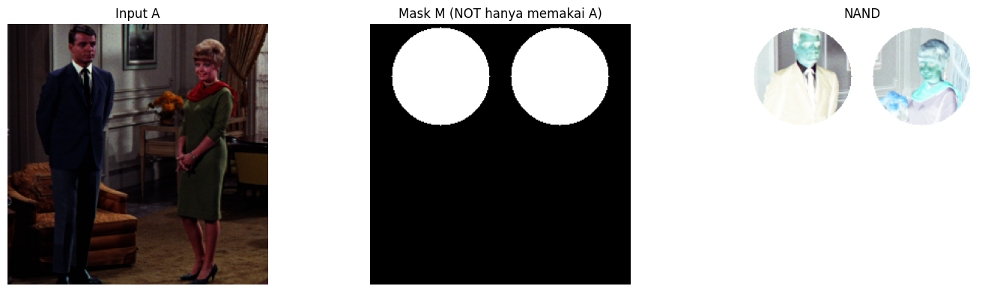

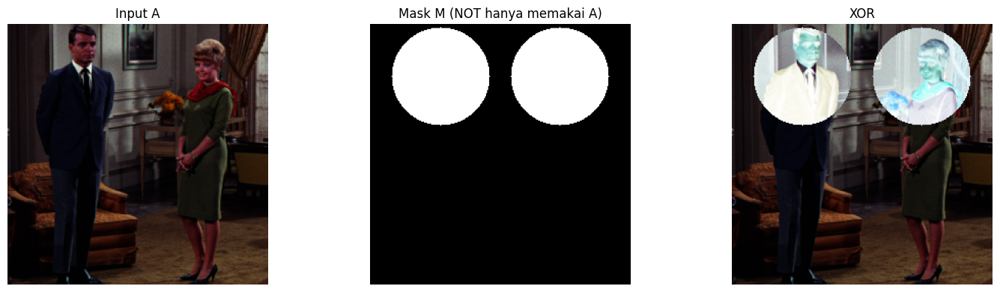

In [20]:
couple = read_image('couple.tiff')
height, width = couple.shape[:2]
mask = np.zeros((height, width), dtype=np.uint8)
radius = int(0.19 * min(height, width))
for cx in (0.27, 0.73):
    cv.circle(mask, (int(cx * width), int(0.20 * height)), radius, 255, -1)
mask_bgr = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
and_image = cv.bitwise_and(couple, mask_bgr)
white_background = cv.bitwise_or(and_image, cv.bitwise_not(mask_bgr))
show_results('09_masking.png', [couple, mask, white_background], ['Asli', 'Mask dua lingkaran', 'Hasil latar putih'], 3)
operators = {'NOT': cv.bitwise_not(couple), 'OR': cv.bitwise_or(couple, mask_bgr),
             'AND': and_image, 'NAND': cv.bitwise_not(and_image),
             'XOR': cv.bitwise_xor(couple, mask_bgr)}
for name, result in operators.items():
    show_results(f'09_{name.lower()}.png', [couple, mask, result],
                 ['Input A', 'Mask M (NOT hanya memakai A)', name], 3)

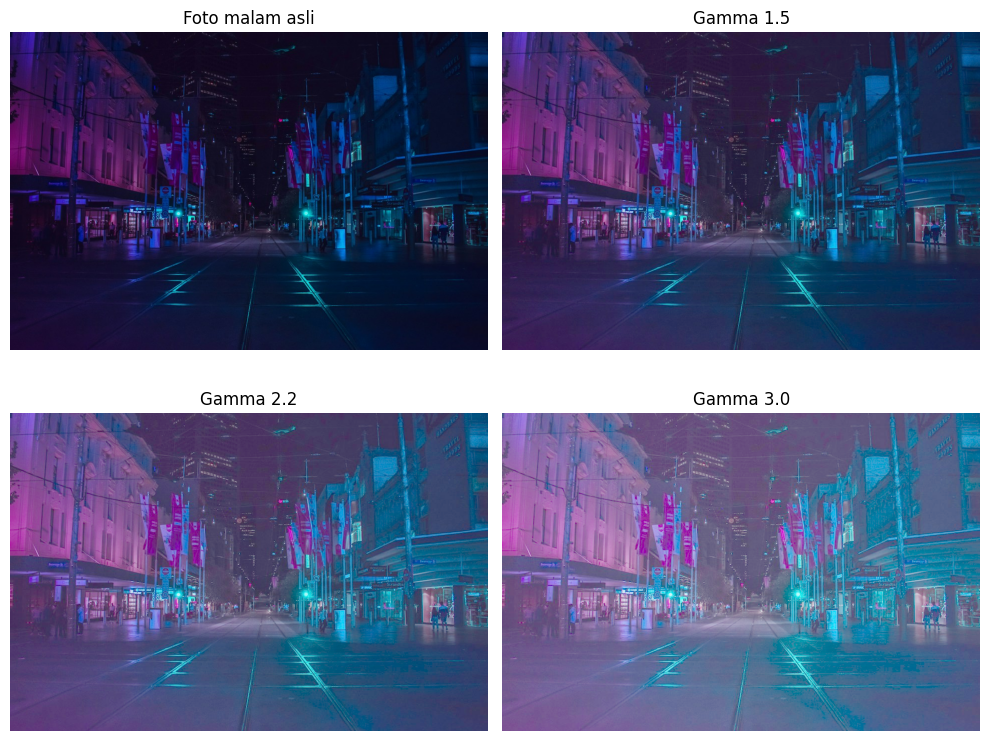

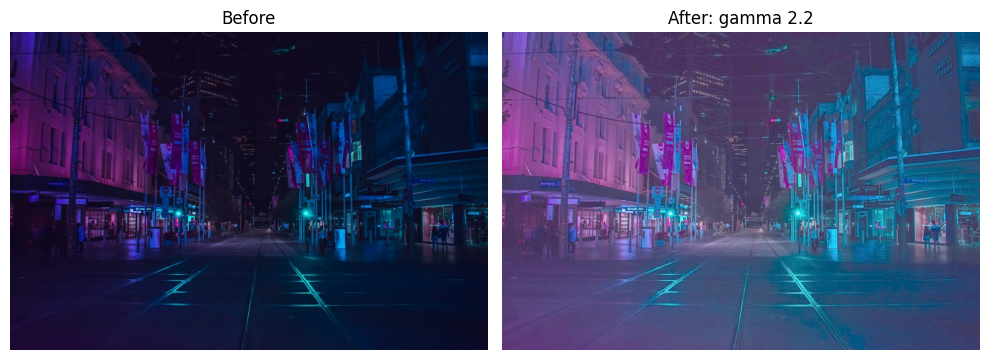

Sumber foto: https://images.unsplash.com/photo-1519608487953-e999c86e7455?w=960&q=85&fit=crop


80

In [21]:
from urllib.request import Request, urlopen
night_source = 'https://images.unsplash.com/photo-1519608487953-e999c86e7455?w=960&q=85&fit=crop'
night_path = DATA_DIR / 'night.jpg'
if not night_path.exists():
    request = Request(night_source, headers={'User-Agent': 'PCVK-Praktikum/1.0'})
    with urlopen(request, timeout=60) as response:
        payload = response.read()
    if cv.imdecode(np.frombuffer(payload, dtype=np.uint8), cv.IMREAD_COLOR) is None:
        raise ValueError('Unduhan foto malam bukan citra yang valid.')
    night_path.write_bytes(payload)
night = read_image('night.jpg')
night_gamma = 2.2
night_result = gamma_correction(night, night_gamma)
show_results('10_night_candidates.png', [night] + [gamma_correction(night, g) for g in (1.5, 2.2, 3.0)],
             ['Foto malam asli', 'Gamma 1.5', 'Gamma 2.2', 'Gamma 3.0'])
show_results('10_night.png', [night, night_result], ['Before', f'After: gamma {night_gamma}'])
print('Sumber foto:', night_source)
(OUTPUT_DIR / 'night_source.txt').write_text(night_source, encoding='utf-8')

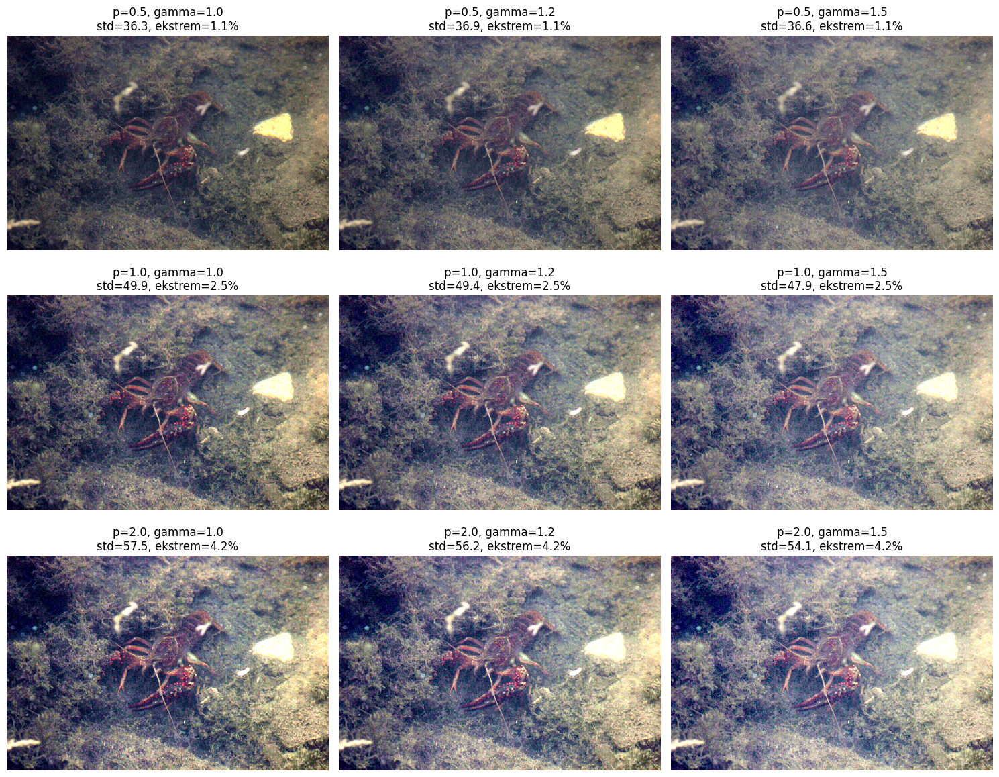

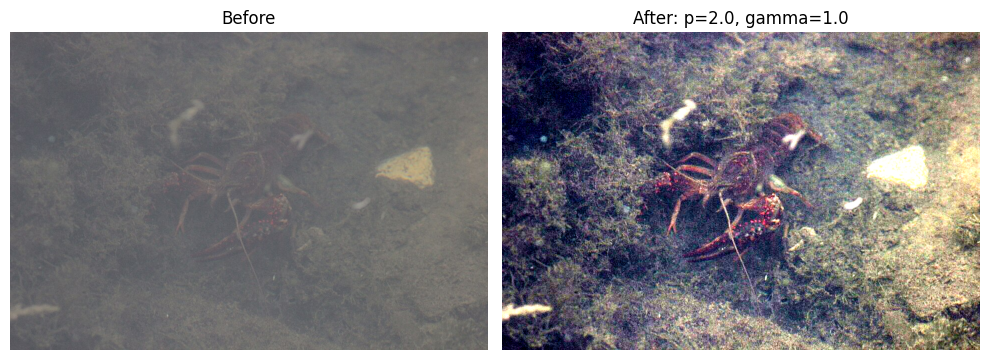

Parameter terpilih menurut kriteria numerik: persentil 2.0–98.0, low=91.00, high=128.00, gamma=1.0. Mean=110.53, std=57.47, sampel kanal ekstrem=4.19%.

245

In [22]:
crayfish = read_image('crayfish.jpg')
candidates, candidate_rows = [], []
for percentile in (0.5, 1.0, 2.0):
    low, high = np.percentile(crayfish.astype(np.float64), [percentile, 100-percentile])
    if high <= low:
        raise ValueError('Rentang intensitas crayfish terlalu sempit untuk stretching.')
    stretched = uint8((crayfish.astype(np.float64) - low) * 255 / (high - low))
    for g in (1.0, 1.2, 1.5):
        result = gamma_correction(stretched, g)
        gray = cv.cvtColor(result, cv.COLOR_BGR2GRAY)
        mean, std = float(gray.mean()), float(gray.std())
        clipped = float(100 * np.mean((result == 0) | (result == 255)))
        candidates.append(result)
        candidate_rows.append({'persentil': percentile, 'gamma': g, 'low': float(low),
                               'high': float(high), 'mean': mean, 'std': std, 'ekstrem_pct': clipped})
show_results('11_candidates.png', candidates,
             [f'p={r["persentil"]}, gamma={r["gamma"]}\nstd={r["std"]:.1f}, ekstrem={r["ekstrem_pct"]:.1f}%' for r in candidate_rows], 3)
eligible = [i for i, r in enumerate(candidate_rows) if r['ekstrem_pct'] <= 5 and 70 <= r['mean'] <= 180]
if not eligible:
    raise ValueError('Tidak ada kandidat memenuhi kriteria; evaluasi gambar kandidat dan sesuaikan parameter.')
best_index = max(eligible, key=lambda i: candidate_rows[i]['std'])
best = candidate_rows[best_index]
crayfish_result = candidates[best_index]
show_results('11_crayfish.png', [crayfish, crayfish_result],
             ['Before', f'After: p={best["persentil"]}, gamma={best["gamma"]}'])
with (OUTPUT_DIR / 'crayfish_parameters.csv').open('w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=list(best))
    writer.writeheader()
    writer.writerows(candidate_rows)
summary = (f'Parameter terpilih menurut kriteria numerik: persentil {best["persentil"]}–{100-best["persentil"]}, '
           f'low={best["low"]:.2f}, high={best["high"]:.2f}, gamma={best["gamma"]}. '
           f'Mean={best["mean"]:.2f}, std={best["std"]:.2f}, sampel kanal ekstrem={best["ekstrem_pct"]:.2f}%.')
display(Markdown(summary))
(OUTPUT_DIR / 'crayfish.md').write_text('# Hasil perbaikan crayfish\n\n' + summary +
    '\n\n![Before-after](11_crayfish.png)\n\n![Kandidat](11_candidates.png)', encoding='utf-8')